In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm, binom
from matplotlib import pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
import os

Loading the dataframe

In [2]:
shots=pd.read_csv(os.path.join("data","shots_all_seasons.csv"), low_memory=False)

shots.head()


,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Above the Break 3,Left Side Center,LC,24+ ft.,20.0,21.35,25,6,0,0
1,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,6,0,2
2,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Mid-Range,Left Side Center,LC,16-24 ft.,13.3,24.45,23,6,0,9
3,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Left Side,L,16-24 ft.,16.4,13.95,18,6,0,31
4,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Right Side,R,16-24 ft.,-15.8,7.85,16,6,0,55


In [3]:
shots.tail()

,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
4450784,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,-1.5,5.35,1,4,3,14
4450785,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Above the Break 3,Right Side Center,RC,24+ ft.,-18.3,31.95,32,4,2,53
4450786,2025,2024-25,1610612764,Washington Wizards,1642259,Alex Sarr,NaN,NaN,12-15-2024,22401217,...,Right Corner 3,Right Side,R,24+ ft.,-22.9,8.45,23,4,2,11
4450787,2025,2024-25,1610612764,Washington Wizards,1630551,Justin Champagnie,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,0.7,6.65,1,4,1,45
4450788,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,-1.7,6.95,2,4,1,20


Plotting the court for visual examples

<Axes: >

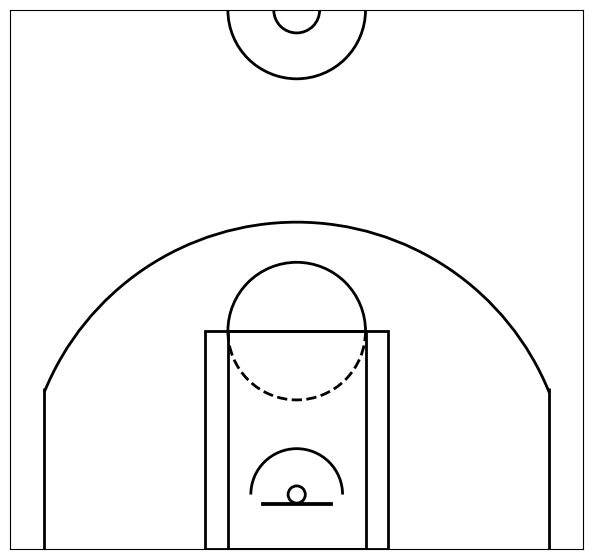

In [4]:

fig, ax = plt.subplots(figsize=(10, 7))
def draw_court(ax=None, color='black', lw=2, outer_lines=False, interval=20):
    if ax is None:
        ax = plt.gca()

    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0, linewidth=lw, color=color)
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                    bottom_free_throw, restricted, corner_three_a,
                    corner_three_b, three_arc, center_outer_arc,
                    center_inner_arc]

    if outer_lines:
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,color=color, fill=False)
        court_elements.append(outer_lines)

    for element in court_elements:
        ax.add_patch(element)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

draw_court(ax)

Analyzed season played by said player

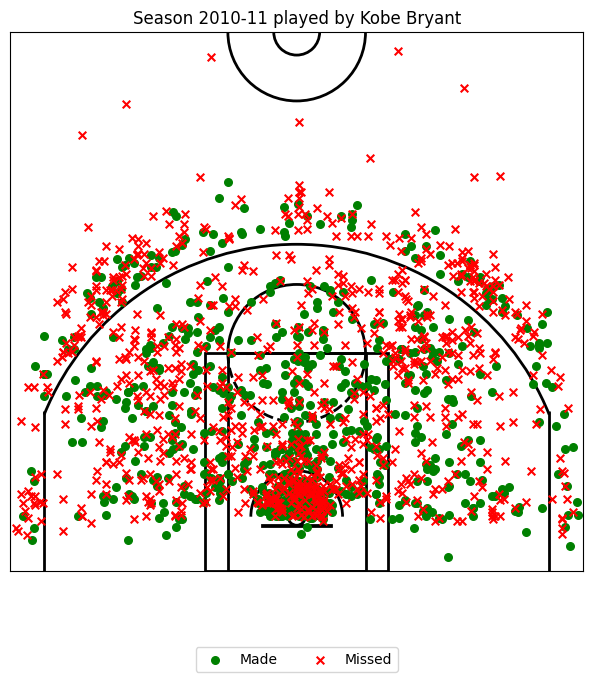

In [20]:
player = 'Kobe Bryant'
season = 2011
shotsfiltered=shots[
    (shots['SEASON_1'] == season) & 
    (shots['PLAYER_NAME'] == player) &
    (shots['SHOT_DISTANCE'] >=0)
]

made_shots = shotsfiltered[shotsfiltered['SHOT_MADE'] == True]
missed_shots = shotsfiltered[shotsfiltered['SHOT_MADE'] == False]

completeseason = (shotsfiltered['SEASON_2']).iloc[0]

fig, ax = plt.subplots(figsize=(10, 7))

draw_court(ax)

offset=51.7

ax.scatter(made_shots['LOC_X'] * -10 , made_shots['LOC_Y'] * 10 - offset, 
                    color='green', label='Made', s=30)
ax.scatter(missed_shots['LOC_X'] * -10 , missed_shots['LOC_Y'] * 10 - offset, 
                    color='red', label='Missed', marker='x', s=30)


ax.set_title(f"Season {completeseason} played by {player}")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)


plt.show()

In [6]:
distanzefiltered = np.sqrt(shotsfiltered['LOC_X']**2 + shotsfiltered['LOC_Y']**2)

distanze=distanzefiltered[distanzefiltered<45] #shot before half court

mean = np.mean(distanze)
mode = stats.mode(np.round(distanze), keepdims=True).mode[0] 
varianza = np.var(distanze)
dev_std = np.std(distanze) 
min = np.min(distanze)
max = np.max(distanze)

Gaussian distribution comparison

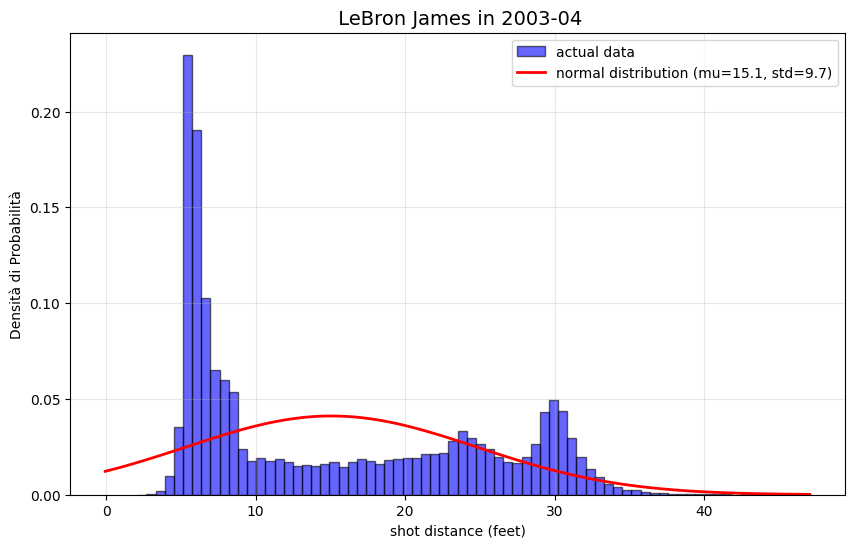

It's almost impossible to get a gaussian normal with basketball shots data as they do not depend on a trend but vary from playerstyles and basketball dynamics


In [7]:
plt.figure(figsize=(10, 6))

plt.hist(distanze, bins=70, density=True, alpha=0.6, color='blue', edgecolor='black', label="actual data")

xmin, xmax = plt.xlim() #saving axes limits

#bell curve generation
x = np.linspace(xmin, xmax, 100) 
p = norm.pdf(x, mean, dev_std) 

plt.plot(x, p, 'r', linewidth=2, label=f'normal distribution (mu={mean:.1f}, std={dev_std:.1f})')

plt.title(f' {player} in {completeseason}', fontsize=14)
plt.xlabel('shot distance (feet)')
plt.ylabel('Densità di Probabilità')
plt.legend()
plt.grid(alpha=0.3)

plt.show()
print("It's almost impossible to get a gaussian normal with basketball shots data as they do not depend on a trend but vary from playerstyles and basketball dynamics" )

In [8]:
universe = shotsfiltered
ntotalshots = len(universe)

threeptshots = universe[universe['SHOT_TYPE'] == '3PT Field Goal']
threeptshots = len(threeptshots)
nshotsmade = len(shotsfiltered[shotsfiltered['SHOT_MADE'] == True])

twoptmade = len(universe[(universe['SHOT_TYPE'] == '2PT Field Goal') & (universe['SHOT_MADE'] == True)])
twoptmissed = len(universe[(universe['SHOT_TYPE'] == '2PT Field Goal') & (universe['SHOT_MADE'] == False)])
threeptmade = len(universe[(universe['SHOT_TYPE'] == '3PT Field Goal') & (universe['SHOT_MADE'] == True)])
threeptmissed = len(universe[(universe['SHOT_TYPE'] == '3PT Field Goal') & (universe['SHOT_MADE'] == False)])

labels = ['2PT Made', '2PT Missed', '3PT Made', '3PT Missed']
threeandtwoshots = [twoptmade, twoptmissed, threeptmade, threeptmissed]
prob3pt = threeptshots / ntotalshots #probability that the shot is from 3pt range 
prob3ptmade = threeptmade / threeptshots #probabilty of the shot to be made (from 3pt range)
probshotmade = nshotsmade / ntotalshots #probability that the shot will be made in general
probshotwas3 = (prob3ptmade * prob3pt) / probshotmade #probability that the shot was a three
verifica = threeptmade / nshotsmade

print(f"{prob3pt:.2%} probability that the shot is from 3pt range ")
print(f"{prob3ptmade:.2%} probabilty of the shot to be made (from 3pt range)")
print(f"{probshotmade:.2%} probability that the shot will be made in general")
print(f"(considering the made shot, there is a {probshotwas3:.1%} chance that said shot is a triple)")
print(f"actual verification with dataset files: {verifica:.2%}")

23.94% probability that the shot is from 3pt range 
34.96% probabilty of the shot to be made (from 3pt range)
50.65% probability that the shot will be made in general
(considering the made shot, there is a 16.5% chance that said shot is a triple)
actual verification with dataset files: 16.52%


LeBron James top 10 most used shot types:
['Jump Shot', 'Driving Layup Shot', 'Layup Shot', 'Fadeaway Jump Shot', 'Pullup Jump shot', 'Step Back Jump shot', 'Turnaround Fadeaway shot', 'Running Layup Shot', 'Turnaround Jump Shot', 'Running Jump Shot']



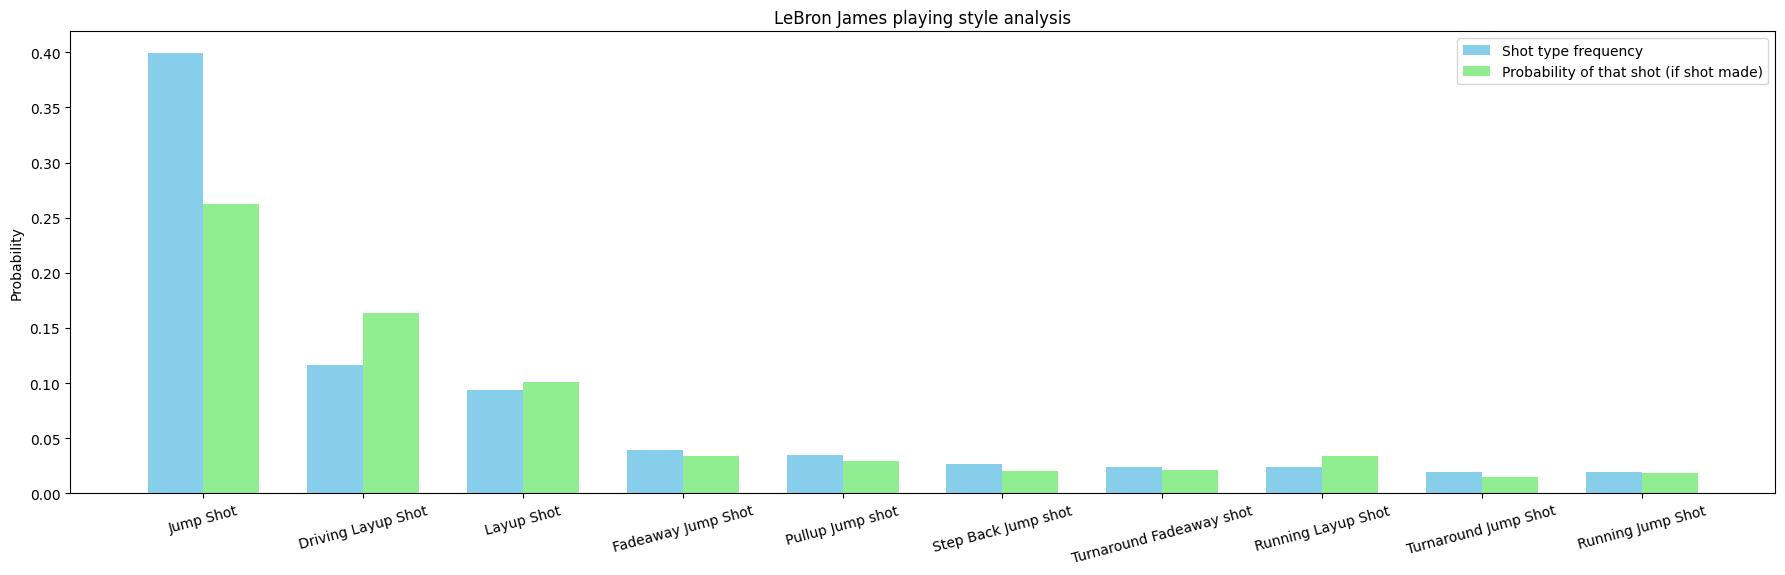

In [9]:
top_actions = shotsfiltered['ACTION_TYPE'].value_counts().nlargest(10).index.tolist()

df_top = shotsfiltered[shotsfiltered['ACTION_TYPE'].isin(top_actions)].copy()

shotmadeprob = shotsfiltered['SHOT_MADE'].mean()

print(f"{player} top 10 most used shot types:")
print(f"{top_actions}\n")
results = []

for action in top_actions:
    subset = shotsfiltered[shotsfiltered['ACTION_TYPE'] == action]
    
    shottypeprob = len(subset) / len(shotsfiltered) #how often that type of shot is chosen by the player?
    
    subshotmadeprob = subset['SHOT_MADE'].mean()
    
    probshotwasaction = (subshotmadeprob * shottypeprob) / shotmadeprob
    
    results.append({
        'Action': action,
        'Prior': shottypeprob,
        'Likelihood': subshotmadeprob,
        'Posterior': probshotwasaction
    })
    


df_res = pd.DataFrame(results).set_index('Action')

fig, ax = plt.subplots(figsize=(22, 6))
x = range(len(df_res))
width = 0.35

ax.bar([i - width/2 for i in x], df_res['Prior'], width, label='Shot type frequency', color='skyblue')
ax.bar([i + width/2 for i in x], df_res['Posterior'], width, label='Probability of that shot (if shot made)', color='lightgreen')

ax.set_ylabel('Probability')
ax.set_title(f'{player} playing style analysis')
ax.set_xticks(x)
ax.set_xticklabels(df_res.index, rotation=15)
ax.legend()

plt.show()

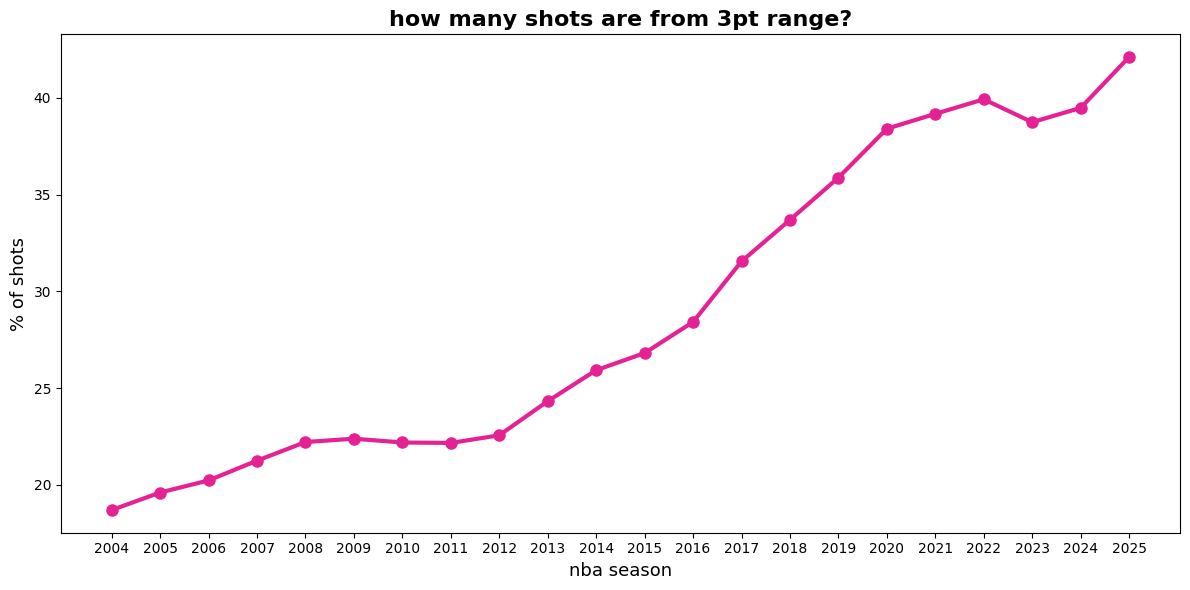

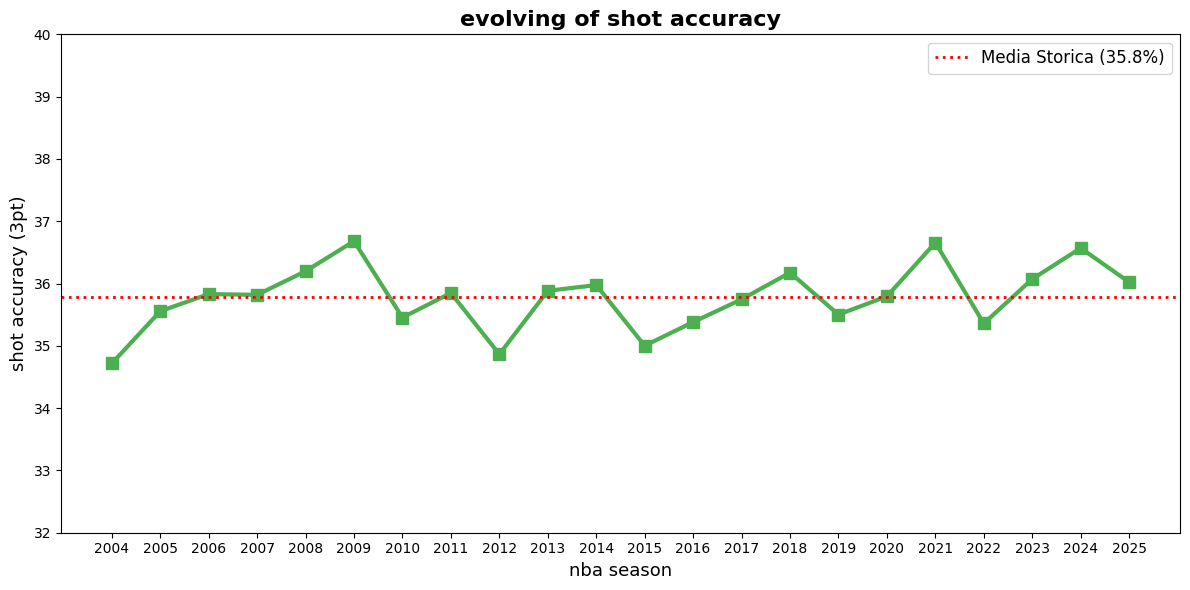

In [10]:
nshots = shots.groupby('SEASON_1').size()
threeptshots = shots[shots['SHOT_TYPE'] == '3PT Field Goal']
n3ptshots = threeptshots.groupby('SEASON_1').size()
nmade3ptshots = threeptshots.groupby('SEASON_1')['SHOT_MADE'].sum()

perc_volume = (n3ptshots / nshots) * 100
perc_precisione = (nmade3ptshots / n3ptshots) * 100

years = perc_volume.index  #puts the years as different single index so that i basically have a list of years to represent 

fig, ax = plt.subplots(figsize=(12, 6)) 

ax.plot(years, perc_volume, marker='o', color="#e52294", linewidth=3, markersize=8)

ax.set_title("how many shots are from 3pt range?", fontsize=16, fontweight='bold')
ax.set_ylabel("% of shots", fontsize=13)
ax.set_xlabel("nba season", fontsize=13)
ax.set_xticks(years)

plt.tight_layout()
plt.show()

#second graph
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(years, perc_precisione, marker='s', color='#4caf50', linewidth=3, markersize=8)
ax.set_title("evolving of shot accuracy", fontsize=16, fontweight='bold')
ax.set_ylabel("shot accuracy (3pt)", fontsize=13)
ax.set_xlabel("nba season", fontsize=13)

ax.set_ylim(32, 40)
ax.set_xticks(years)

# Media storica
media_storica = perc_precisione.mean()
ax.axhline(media_storica, color='red', linestyle=':', linewidth=2, label=f'Media Storica ({media_storica:.1f}%)')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show() # Stampa il secondo grafico

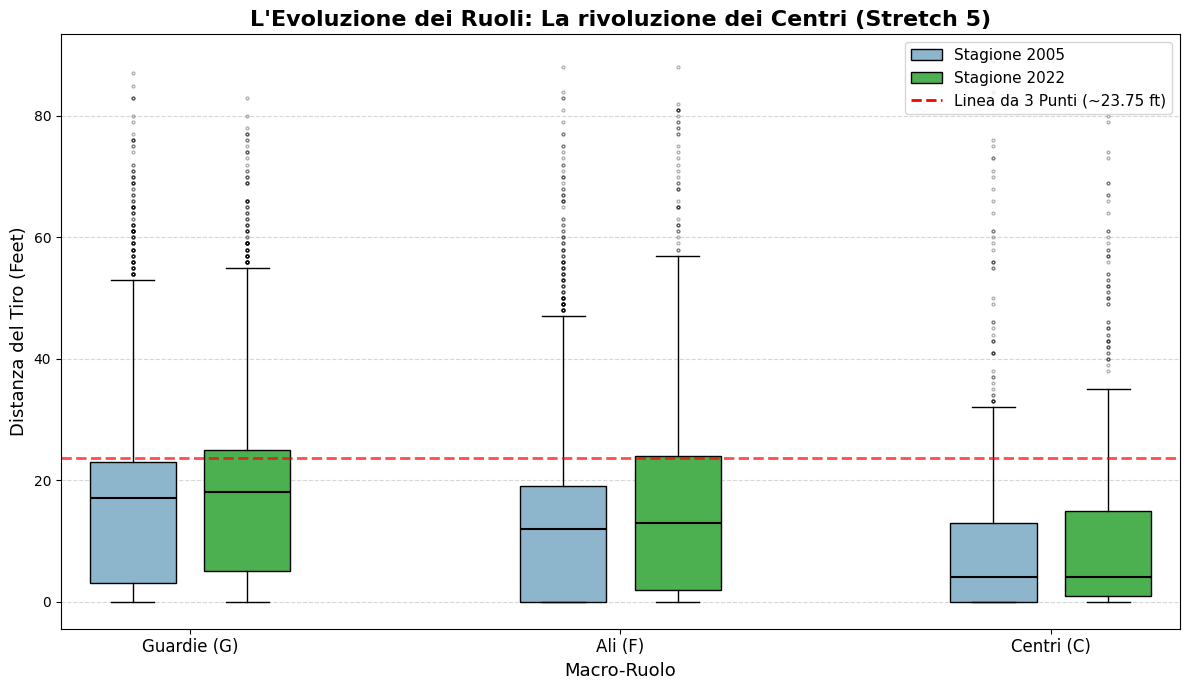

In [11]:
from matplotlib.patches import Patch 

# 1. Selezioniamo le due stagioni
anno_passato = 2005
anno_recente = 2022

# Filtriamo e puliamo i dati
df_box = shots[shots['SEASON_1'].isin([anno_passato, anno_recente])].copy()
df_box = df_box.dropna(subset=['SHOT_DISTANCE', 'POSITION_GROUP'])

ordine_ruoli = ['G', 'F', 'C']

# 2. Prepariamo le liste per Matplotlib
dati_da_plottare = []
posizioni = []
colori = []
etichette_x = []

colore_passato = '#8db6cd' # Azzurro
colore_recente = '#4caf50' # Verde

# Cicliamo sui ruoli per estrarre i dati e calcolare le coordinate X
posizione_corrente = 1 # Punto di partenza sull'asse X

for ruolo in ordine_ruoli:
    # Dati anno passato
    tiri_passato = df_box[(df_box['POSITION_GROUP'] == ruolo) & (df_box['SEASON_1'] == anno_passato)]['SHOT_DISTANCE'].values
    dati_da_plottare.append(tiri_passato)
    posizioni.append(posizione_corrente)
    colori.append(colore_passato)
    
    # Dati anno recente
    tiri_recente = df_box[(df_box['POSITION_GROUP'] == ruolo) & (df_box['SEASON_1'] == anno_recente)]['SHOT_DISTANCE'].values
    dati_da_plottare.append(tiri_recente)
    posizioni.append(posizione_corrente + 0.8) # Mettiamo la scatola nuova poco dopo la prima
    colori.append(colore_recente)
    
    # Calcoliamo il centro esatto tra le due scatole per mettere il nome del ruolo sotto l'asse X
    etichette_x.append(posizione_corrente + 0.4) 
    
    # Lasciamo un po' di spazio prima di passare al ruolo successivo (G -> F -> C)
    posizione_corrente += 3 

# --- 3. CREAZIONE DEL GRAFICO ---
fig, ax = plt.subplots(figsize=(12, 7))

# La funzione boxplot pura di matplotlib
bplot = ax.boxplot(
    dati_da_plottare, 
    positions=posizioni, 
    widths=0.6,
    patch_artist=True, # FONDAMENTALE: permette di colorare l'interno delle scatole
    flierprops=dict(marker='o', color='black', markersize=2, alpha=0.3) # Stile degli outlier
)

# Coloriamo le scatole alternando azzurro e verde
for patch, color in zip(bplot['boxes'], colori):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

# Coloriamo di nero anche le linee della mediana
for median in bplot['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

# 4. Aggiungiamo la linea da 3 punti
ax.axhline(23.75, color='red', linestyle='--', alpha=0.7, linewidth=2)

# 5. Sistemiamo assi e legenda (dobbiamo crearla a mano)
ax.set_xticks(etichette_x)
ax.set_xticklabels(['Guardie (G)', 'Ali (F)', 'Centri (C)'], fontsize=12)

ax.set_title("L'Evoluzione dei Ruoli: La rivoluzione dei Centri (Stretch 5)", fontsize=16, fontweight='bold')
ax.set_xlabel("Macro-Ruolo", fontsize=13)
ax.set_ylabel("Distanza del Tiro (Feet)", fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Creazione della Legenda Personalizzata
elementi_legenda = [
    Patch(facecolor=colore_passato, edgecolor='black', label=f'Stagione {anno_passato}'),
    Patch(facecolor=colore_recente, edgecolor='black', label=f'Stagione {anno_recente}'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Linea da 3 Punti (~23.75 ft)')
]
ax.legend(handles=elementi_legenda, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

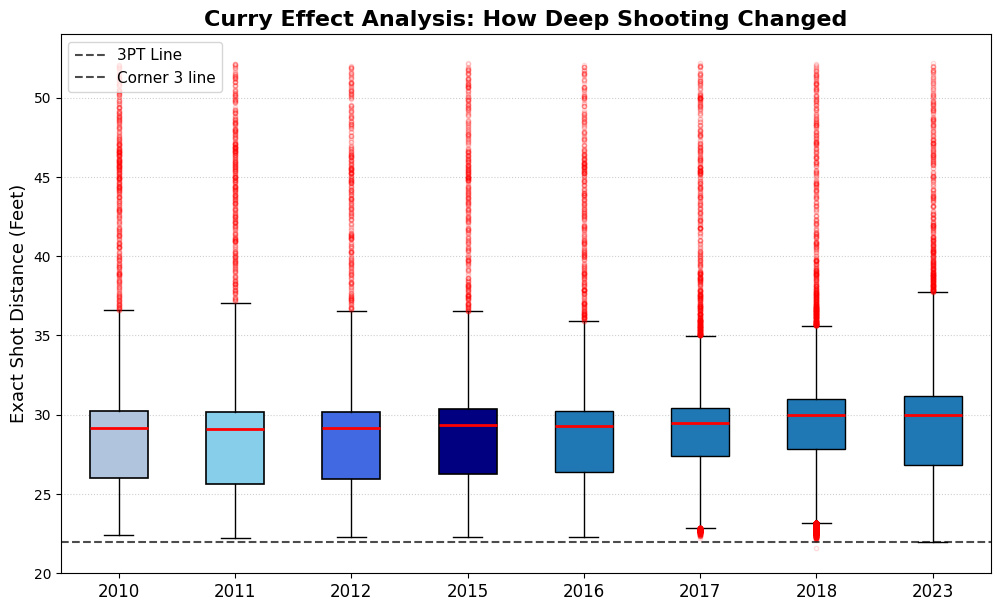

In [12]:
target_seasons = [2010, 2011, 2012,2015,2016, 2017, 2018, 2023]
dati_da_plottare = []

shots['EXACT_DISTANCE'] = np.sqrt(shots['LOC_X']**2 + shots['LOC_Y']**2) 

df_deep = shots[
    (shots['SHOT_TYPE'] == '3PT Field Goal') & 
    (shots['SEASON_1'].isin(target_seasons))
].copy()

for season in target_seasons:

    df_filtered = df_deep[(df_deep['SEASON_1'] == season) & 
                          (df_deep['SHOT_DISTANCE'] < 47) & 
                          (df_deep['SHOT_DISTANCE'] >1) & 
                          ~(df_deep['ACTION_TYPE'] == 'Right Corner 3') & 
                          ~(df_deep['ACTION_TYPE'] == 'Left Corner 3')]
    distanze = df_filtered['EXACT_DISTANCE'].values
        
    dati_da_plottare.append(distanze)

colori_scatole = ['#b0c4de', '#87ceeb', '#4169e1', '#000080'] 

fig, ax = plt.subplots(figsize=(12, 7))

bplot = ax.boxplot(
    dati_da_plottare,
    patch_artist=True,
    widths=0.5,
    flierprops=dict(marker='o', color='red', markeredgecolor='red', markersize=3, alpha=0.15)
)

for patch, color in zip(bplot['boxes'], colori_scatole):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)

for median in bplot['medians']:
    median.set_color('red')
    median.set_linewidth(2)


ax.set_xticks(np.arange(1, len(target_seasons) + 1))
ax.set_xticklabels([f"{anno}" for anno in target_seasons], fontsize=12)

ax.set_title("Curry Effect Analysis: How Deep Shooting Changed", fontsize=16, fontweight='bold')
ax.set_ylabel("Exact Shot Distance (Feet)", fontsize=13)

ax.axhline(23,75, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='3PT Line')
ax.axhline(22, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='Corner 3 line')

ax.set_ylim(20, 54)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)

plt.show()

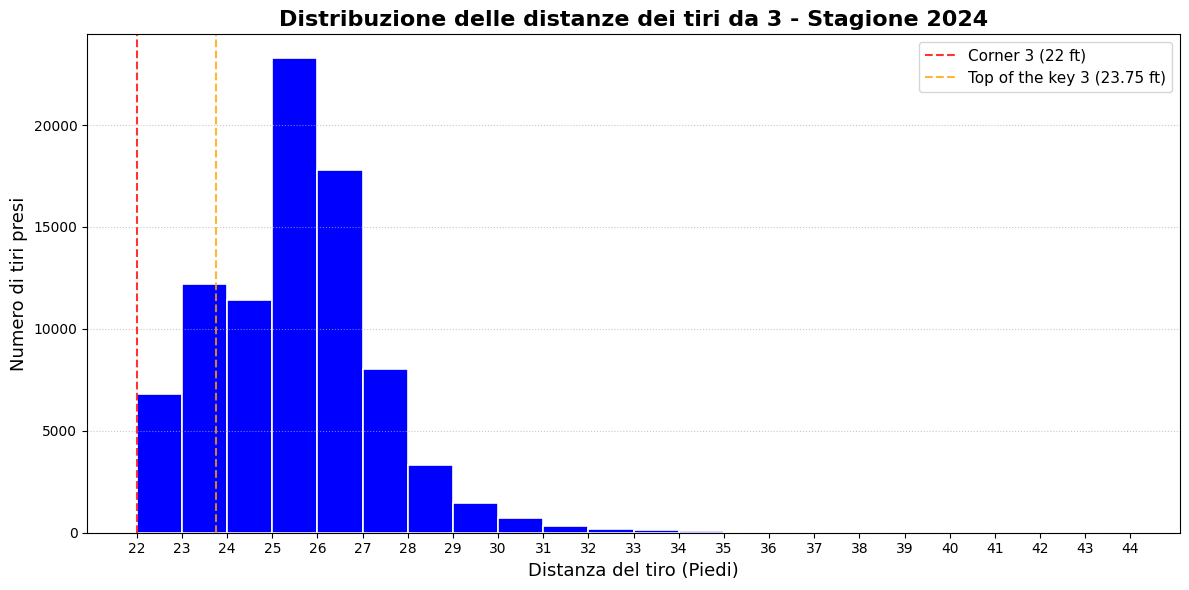

In [13]:
season = 2024

df = shots[
    (shots['SEASON_1'] == season) & 
    (shots['SHOT_TYPE'] == '3PT Field Goal')
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['SHOT_DISTANCE'], bins=range(22, 45), color='blue', edgecolor='white', linewidth=1.2)

ax.set_title(f"Distribuzione delle distanze dei tiri da 3 - Stagione {season}", fontsize=16, fontweight='bold')
ax.set_xlabel("Distanza del tiro (Piedi)", fontsize=13)
ax.set_ylabel("Numero di tiri presi", fontsize=13)

ax.axvline(22.0, color='red', linestyle='--', alpha=0.8, label='Corner 3 (22 ft)')
ax.axvline(23.75, color='orange', linestyle='--', alpha=0.8, label='Top of the key 3 (23.75 ft)')

ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.set_xticks(range(22, 45))
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

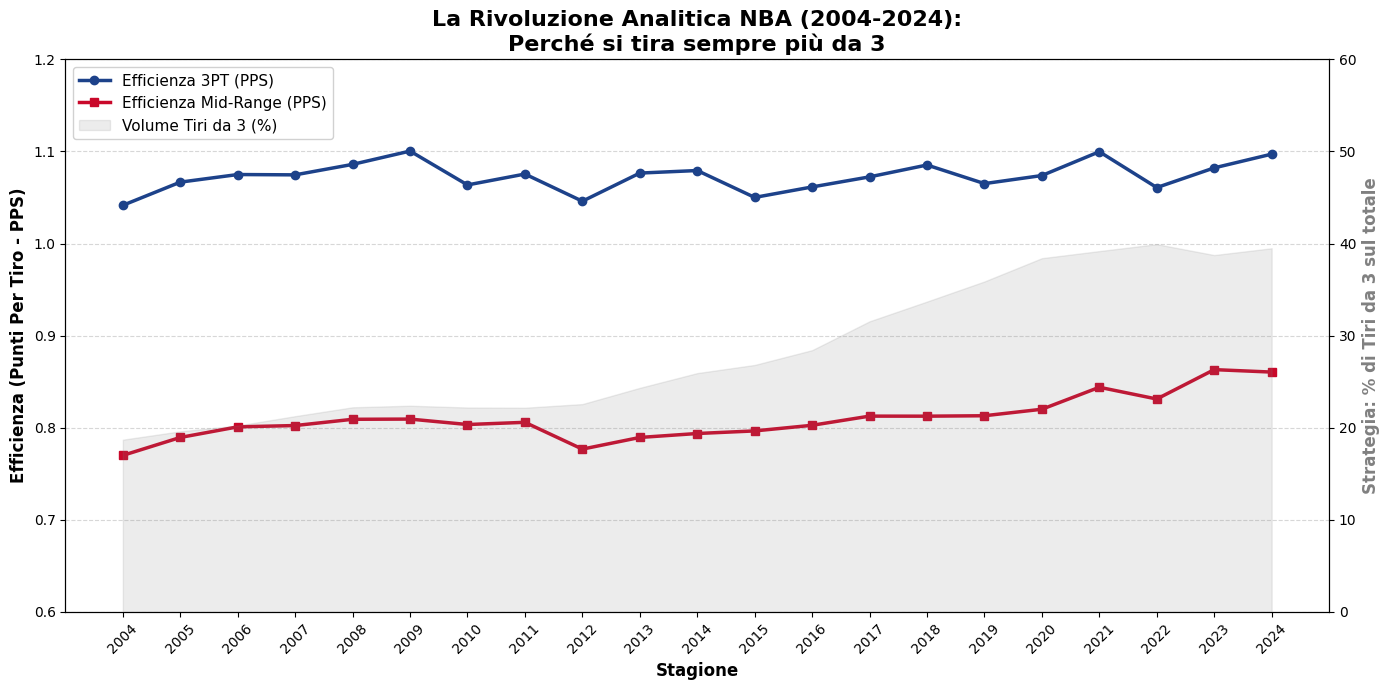

In [14]:
anni_analisi = range(2004, 2025)
df_eff = shots[(shots['SEASON_1'].isin(anni_analisi))].copy()

df_eff['IS_MADE'] = np.where(df_eff['SHOT_MADE'].isin([True, 1, '1', 'Made Shot']), 1, 0)

df_eff['PT_VALUE'] = np.where(df_eff['SHOT_TYPE'] == '3PT Field Goal', 3, 2)
df_eff['POINTS_EARNED'] = df_eff['IS_MADE'] * df_eff['PT_VALUE']

condizioni = [
    df_eff['SHOT_TYPE'] == '3PT Field Goal',
    (df_eff['SHOT_TYPE'] != '3PT Field Goal') & (df_eff['SHOT_DISTANCE'] > 10), # Mid-range (inefficiente)
    (df_eff['SHOT_TYPE'] != '3PT Field Goal') & (df_eff['SHOT_DISTANCE'] <= 10) # Area pitturata (efficiente)
]
scelte = ['3PT', 'Mid-Range', 'Paint']
df_eff['ZONE'] = np.select(condizioni, scelte, default='Unknown')

# 5. Raggruppiamo i dati anno per anno
# Calcoliamo l'Efficienza (Media Punti Per Tiro)
efficienza = df_eff.groupby(['SEASON_1', 'ZONE'])['POINTS_EARNED'].mean().unstack()

# Calcoliamo il Volume (Percentuale di tiri da 3 sul totale)
volume = df_eff.groupby(['SEASON_1', 'ZONE']).size().unstack()
volume['Total'] = volume.sum(axis=1)
volume['3PT_Pct'] = (volume['3PT'] / volume['Total']) * 100

fig, ax1 = plt.subplots(figsize=(14, 7))

# Asse Sinistro (Efficienza: Punti per tiro)
ax1.plot(efficienza.index, efficienza['3PT'], color='#1d428a', marker='o', linewidth=2.5, label='Efficienza 3PT (PPS)')
ax1.plot(efficienza.index, efficienza['Mid-Range'], color='#c9082a', marker='s', linewidth=2.5, label='Efficienza Mid-Range (PPS)')

ax1.set_xlabel('Stagione', fontsize=12, fontweight='bold')
ax1.set_ylabel('Efficienza (Punti Per Tiro - PPS)', fontsize=12, fontweight='bold', color='black')
ax1.set_ylim(0.6, 1.2) # Il range logico dei Punti Per Tiro
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Asse Destro (Volume Strategico: Percentuale di tiri da 3)
ax2 = ax1.twinx()
# Usiamo un grafico ad area sfumata in background per far vedere come è aumentato il volume
ax2.fill_between(volume.index, volume['3PT_Pct'], color='gray', alpha=0.15, label='Volume Tiri da 3 (%)')
ax2.set_ylabel('Strategia: % di Tiri da 3 sul totale', fontsize=12, fontweight='bold', color='gray')
ax2.set_ylim(0, 60)

# Titoli e legende
plt.title('La Rivoluzione Analitica NBA (2004-2024):\nPerché si tira sempre più da 3', fontsize=16, fontweight='bold')

# Combiniamo le legende dei due assi
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, framealpha=0.9)

# Assicuriamoci che tutte le stagioni siano visibili sull'asse X
ax1.set_xticks(anni_analisi)
ax1.set_xticklabels([str(anno) for anno in anni_analisi], rotation=45)

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
#import matplotlib.subplots as plt
import matplotlib.pyplot as plt

# 1. Filtriamo solo i 4 quarti regolamentari (escludiamo gli Overtime > 4 per avere un trend pulito)
# Assicuriamoci che QUARTER sia numerico
shots['QUARTER'] = pd.to_numeric(shots['QUARTER'], errors='coerce')
df_q = shots[shots['QUARTER'].isin([1, 2, 3, 4])].copy()

# 2. Uniformiamo i canestri segnati e calcoliamo i punti
df_q['IS_MADE'] = np.where(df_q['SHOT_MADE'].isin([True, 1, '1', 'Made Shot']), 1, 0)
df_q['PT_VALUE'] = np.where(df_q['SHOT_TYPE'] == '3PT Field Goal', 3, 2)
df_q['POINTS_EARNED'] = df_q['IS_MADE'] * df_q['PT_VALUE']

# 3. Creiamo una colonna semplice: '3PT' o '2PT'
df_q['SHOT_CATEGORY'] = np.where(df_q['SHOT_TYPE'] == '3PT Field Goal', '3PT', '2PT')
l
# 4. Raggruppiamo per Quarto e Categoria di tiro
stats_q = df_q.groupby(['QUARTER', 'SHOT_CATEGORY']).agg(
    fg_pct=('IS_MADE', 'mean'),       # Calcola la % di realizzazione
    pps=('POINTS_EARNED', 'mean'),    # Calcola i Punti Per Tiro
    volume=('IS_MADE', 'count')       # Conta quanti tiri (opzionale, ma utile per controlli)
).unstack()

# --- 5. CREAZIONE DEI GRAFICI AFFIANCATI ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO 1: Precisione (FG%)
ax1.plot(stats_q.index, stats_q['fg_pct']['2PT'] * 100, color='#c9082a', marker='s', markersize=8, linewidth=2.5, label='Precisione 2PT')
ax1.plot(stats_q.index, stats_q['fg_pct']['3PT'] * 100, color='#1d428a', marker='o', markersize=8, linewidth=2.5, label='Precisione 3PT')

ax1.set_title('Effetto Fatica: Precisione nei 4 Quarti', fontsize=14, fontweight='bold')
ax1.set_xlabel('Quarto di Gioco', fontsize=12)
ax1.set_ylabel('Percentuale di Realizzazione (%)', fontsize=12)
ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=11)

# GRAFICO 2: Efficienza (PPS)
ax2.plot(stats_q.index, stats_q['pps']['2PT'], color='#c9082a', marker='s', markersize=8, linewidth=2.5, linestyle='--', label='Efficienza 2PT (PPS)')
ax2.plot(stats_q.index, stats_q['pps']['3PT'], color='#1d428a', marker='o', markersize=8, linewidth=2.5, linestyle='--', label='Efficienza 3PT (PPS)')

ax2.set_title('Efficienza Assoluta: Punti Per Tiro (PPS)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Quarto di Gioco', fontsize=12)
ax2.set_ylabel('Punti Per Tiro (Valore Atteso)', fontsize=12)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], fontsize=11)

# Aggiungiamo la soglia magica di 1.0 PPS
ax2.axhline(1.0, color='green', linestyle=':', linewidth=2, label='Soglia Efficienza (1.0 PPS)')

ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

NameError: name 'l' is not defined

fare le percentuali di riuscita tiro in base alla distanza per capire se effettivamente rimane conveniente tirare da lontano o dopo una certa distanza a sto punto conviene tirare da più vicino o altrimenti da due punti

premessa sul fatto che rappresenti solo alcuni anni
Evoluzione dei tiri da 3 punti, è cambiato il trend? si tira in modo diverso? si tira da più lontano? se sì, perché?
esposizioni:
-grafico del campo con i tiri di un giocatore di un anno e di un altro (2005, 2017)
-stesso grafico ma a barre con la distribuzione dei tiri (evidenzia che non è una normale)
-distribuzione dei tiri da 3 (e avvicinamento alla normale), fatti la domanda "come mai si allontanano di più dal canestro per fare tiri che valgono sempre 3?"
-evoluzione di percentuale di tiri da 3 sul totale dei tiri presi con evoluzione percentuali
-controllo confrontando con tiri dalla media se l'efficienza rimane positiva (tipo se dalla media tiri al 50% da 3 devi tirare al 33% almeno per fare più punti per tiro) e vedi quali stagioni sono con efficienza positiva
-le percentuali di riuscita tiri sono però rimaste uguali nella lega, il segreto è nel fatto che più giocatori hanno iniziato a tirare da 3 punti con percentuali più alte (le guardie hanno la stessa percentuale ma tirano da casa loro e altri ruoli hanno iniziato a tirare dalle stesse distanze)
-analisi nei quarti e conferma del fatto che si è molto più efficienti senza stanchezza (fai un check eliminando i tiri che sono negli ultimi 3 secondi)
-



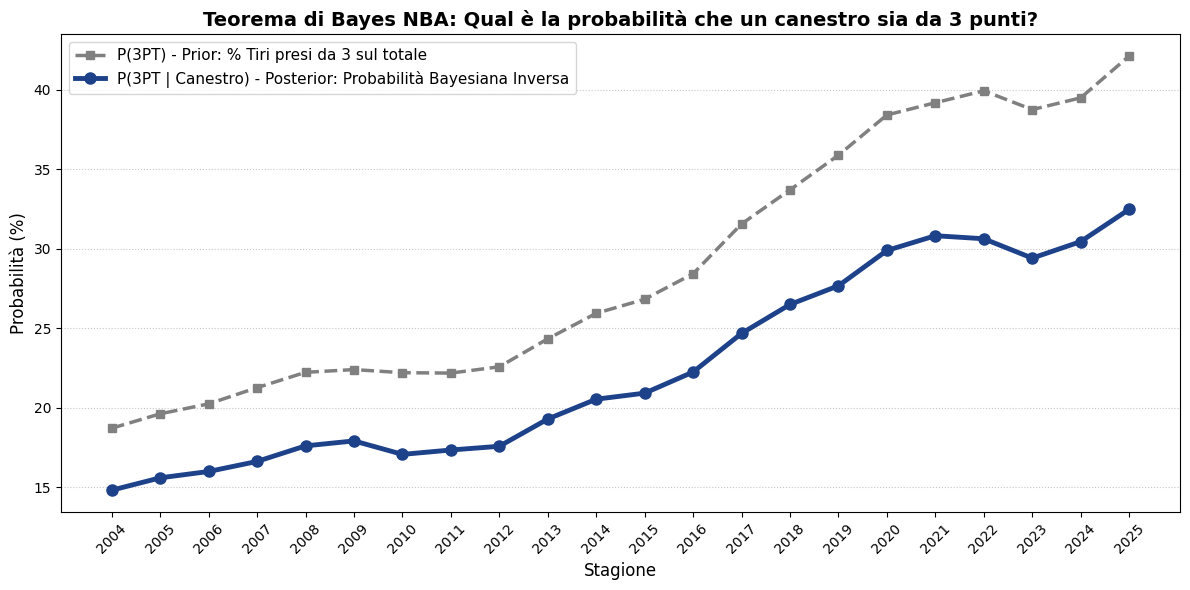

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepariamo i dati partendo dal dataset completo
df_bayes = shots.copy()

# Uniformiamo la colonna dei canestri (1 se segnato, 0 se sbagliato)
df_bayes['IS_MADE'] = np.where(df_bayes['SHOT_MADE'].isin([True, 1, '1', 'Made Shot']), 1, 0)

# Creiamo le variabili per identificare i tiri da 3 punti e i tiri da 3 segnati
df_bayes['IS_3PT'] = np.where(df_bayes['SHOT_TYPE'] == '3PT Field Goal', 1, 0)
df_bayes['3PT_MADE'] = np.where((df_bayes['IS_3PT'] == 1) & (df_bayes['IS_MADE'] == 1), 1, 0)

# 2. Calcoliamo i totali aggregati per ogni singola stagione
bayes_stats = df_bayes.groupby('SEASON_1').agg(
    Total_Att=('IS_MADE', 'count'),       # Totale tiri tentati (tutti)
    Total_Made=('IS_MADE', 'sum'),        # Totale tiri segnati (tutti)
    Att_3PT=('IS_3PT', 'sum'),            # Totale tiri da 3 tentati
    Made_3PT=('3PT_MADE', 'sum')          # Totale tiri da 3 segnati
).reset_index()

# --- 3. IL TEOREMA DI BAYES (La Matematica) ---

# P(3PT) = Prior: Probabilità a priori che un tiro preso sia da 3
bayes_stats['P_3PT'] = bayes_stats['Att_3PT'] / bayes_stats['Total_Att']

# P(Canestro | 3PT) = Likelihood: Probabilità di segnare sapendo che il tiro è da 3 (FG% da 3)
bayes_stats['P_Made_given_3PT'] = bayes_stats['Made_3PT'] / bayes_stats['Att_3PT']

# P(Canestro) = Marginal: Probabilità globale di segnare un tiro qualsiasi (FG% globale)
bayes_stats['P_Made'] = bayes_stats['Total_Made'] / bayes_stats['Total_Att']

# P(3PT | Canestro) = Posterior: LA FORMULA DI BAYES
bayes_stats['P_3PT_given_Made'] = (bayes_stats['P_Made_given_3PT'] * bayes_stats['P_3PT']) / bayes_stats['P_Made']

# --- 4. CREAZIONE DEL GRAFICO ---
fig, ax = plt.subplots(figsize=(12, 6))

# Linea del Prior P(3PT)
ax.plot(bayes_stats['SEASON_1'], bayes_stats['P_3PT'] * 100, 
        color='gray', linestyle='--', linewidth=2.5, marker='s', markersize=6,
        label='P(3PT) - Prior: % Tiri presi da 3 sul totale')

# Linea del Posterior P(3PT | Canestro)
ax.plot(bayes_stats['SEASON_1'], bayes_stats['P_3PT_given_Made'] * 100, 
        color='#1d428a', linewidth=3.5, marker='o', markersize=8, 
        label='P(3PT | Canestro) - Posterior: Probabilità Bayesiana Inversa')

# Estetica e formattazione
ax.set_title("Teorema di Bayes NBA: Qual è la probabilità che un canestro sia da 3 punti?", 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Stagione', fontsize=12)
ax.set_ylabel('Probabilità (%)', fontsize=12)

# Griglia e assi
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.set_xticks(bayes_stats['SEASON_1'])
plt.xticks(rotation=45)

# Legenda
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

esiste un giocatore che spicca rispetto agli altri in una stagione per stile di gioco/tipologia di tiri presi?
quanto è cambiato lo stile di gioco dei giocatori negli years?

In [ ]:
#sapendo che il tiro è stato segnato qual è la probabilità che sia stato segnato da 3 punti
#rispetto ai quarti come rende la percentuale da 3 punti